# Actividad 2 — Pesos Espaciales con la Región Metropolitana

**Curso:** Análisis de Datos Espaciales · USM  
**Duración:** ~60 minutos  
**Datos:** Comunas de la Región Metropolitana (Censo 2017)

En esta actividad van a aplicar los métodos de matrices de pesos espaciales que vimos en clase, pero ahora sobre la geometría real de las comunas de la RM.

---
## Setup

In [109]:
import geopandas as gpd
from libpysal import weights
import matplotlib.pyplot as plt
import pandas as pd

# Leer cartografía de comunas de la RM
rm_comunas = gpd.read_file("/content/Data/COMUNA_C17.shp")


# Reproyectar a UTM zona 19S (metros) — necesario para distancias
rm_comunas = rm_comunas.to_crs(epsg=32719)

# Índice por nombre de comuna (útil para graficar y consultar vecinos)
rm_comunas_idx = rm_comunas.set_index("NOM_COMUNA")

rm_comunas_idx.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,SHAPE_Leng,SHAPE_Area,geometry
NOM_COMUNA,,,,,,,,
PAINE,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,1.625330,0.066035,"POLYGON ((350033.92 6265707.472, 350106.705 62..."
BUIN,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,0.884164,0.021166,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
PUDAHUEL,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,0.720176,0.019124,"POLYGON ((333540.425 6307203.281, 333624.972 6..."
CERRO NAVIA,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,0.170180,0.001076,"POLYGON ((340136.215 6301567.277, 340172.841 6..."
COLINA,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,1.692007,0.093820,"POLYGON ((350790.367 6352972.781, 350751.311 6..."
TILTIL,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13303,1.330148,0.063169,"POLYGON ((337992.739 6355760.045, 338145.413 6..."
LAMPA,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13302,1.046716,0.043569,"POLYGON ((332709.295 6328233.777, 332807.572 6..."
HUECHURABA,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13107,0.326251,0.004350,"POLYGON ((345209.472 6310978.76, 345243.136 63..."
CONCHALÍ,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13104,0.138248,0.001077,"POLYGON ((342734.23 6306883.661, 342746.904 63..."


---
## Ejercicio 1 — Queen vs Rook (15 min)

### Parte A: Construcción y visualización

Construyan las matrices de pesos **Queen** y **Rook** para las comunas de la RM. Usen `ids="NOM_COMUNA"` para que los vecinos se identifiquen por nombre.

Visualicen ambos grafos de vecindad **lado a lado** (1 fila, 2 columnas).

In [96]:
w_rook = weights.contiguity.Rook.from_dataframe(rm_comunas_idx, ids=rm_comunas_idx.index)
w_queen = weights.contiguity.Queen.from_dataframe(rm_comunas_idx, ids=rm_comunas_idx.index)

In [97]:
print(w_rook.neighbors)

{'PAINE': ['MELIPILLA', 'PIRQUE', 'ALHUÉ', 'ISLA DE MAIPO', 'BUIN'], 'BUIN': ['PIRQUE', 'PAINE', 'ISLA DE MAIPO', 'SAN BERNARDO'], 'PUDAHUEL': ['MAIPÚ', 'LAMPA', 'CURACAVÍ', 'RENCA', 'CERRO NAVIA', 'QUILICURA', 'LO PRADO', 'ESTACIÓN CENTRAL'], 'CERRO NAVIA': ['QUINTA NORMAL', 'PUDAHUEL', 'LO PRADO', 'RENCA'], 'COLINA': ['LAMPA', 'TILTIL', 'HUECHURABA', 'LO BARNECHEA', 'QUILICURA'], 'TILTIL': ['COLINA', 'LAMPA'], 'LAMPA': ['COLINA', 'PUDAHUEL', 'CURACAVÍ', 'TILTIL', 'QUILICURA'], 'HUECHURABA': ['COLINA', 'RECOLETA', 'VITACURA', 'LO BARNECHEA', 'QUILICURA', 'CONCHALÍ'], 'CONCHALÍ': ['INDEPENDENCIA', 'RENCA', 'RECOLETA', 'HUECHURABA', 'QUILICURA'], 'MARÍA PINTO': ['MELIPILLA', 'CURACAVÍ'], 'CURACAVÍ': ['MAIPÚ', 'PUDAHUEL', 'LAMPA', 'MELIPILLA', 'PADRE HURTADO', 'MARÍA PINTO'], 'LA PINTANA': ['LA FLORIDA', 'SAN RAMÓN', 'SAN BERNARDO', 'PUENTE ALTO', 'LA GRANJA', 'EL BOSQUE'], 'EL BOSQUE': ['SAN RAMÓN', 'LA PINTANA', 'LA CISTERNA', 'SAN BERNARDO'], 'ESTACIÓN CENTRAL': ['PUDAHUEL', 'QUINTA N

In [98]:
print(w_queen.neighbors)

{'PAINE': ['MELIPILLA', 'PIRQUE', 'ALHUÉ', 'ISLA DE MAIPO', 'BUIN'], 'BUIN': ['PAINE', 'SAN BERNARDO', 'PIRQUE', 'PUENTE ALTO', 'ISLA DE MAIPO'], 'PUDAHUEL': ['MAIPÚ', 'LAMPA', 'CURACAVÍ', 'RENCA', 'CERRO NAVIA', 'QUILICURA', 'LO PRADO', 'ESTACIÓN CENTRAL'], 'CERRO NAVIA': ['QUINTA NORMAL', 'PUDAHUEL', 'LO PRADO', 'RENCA'], 'COLINA': ['LAMPA', 'TILTIL', 'HUECHURABA', 'LO BARNECHEA', 'QUILICURA'], 'TILTIL': ['COLINA', 'LAMPA'], 'LAMPA': ['COLINA', 'PUDAHUEL', 'CURACAVÍ', 'TILTIL', 'QUILICURA'], 'HUECHURABA': ['COLINA', 'RECOLETA', 'VITACURA', 'LO BARNECHEA', 'QUILICURA', 'CONCHALÍ'], 'CONCHALÍ': ['INDEPENDENCIA', 'RENCA', 'RECOLETA', 'HUECHURABA', 'QUILICURA'], 'MARÍA PINTO': ['MELIPILLA', 'CURACAVÍ'], 'CURACAVÍ': ['MAIPÚ', 'PUDAHUEL', 'LAMPA', 'MELIPILLA', 'PADRE HURTADO', 'MARÍA PINTO'], 'LA PINTANA': ['LA FLORIDA', 'SAN RAMÓN', 'SAN BERNARDO', 'PUENTE ALTO', 'LA GRANJA', 'EL BOSQUE'], 'EL BOSQUE': ['SAN RAMÓN', 'LA PINTANA', 'LA CISTERNA', 'SAN BERNARDO'], 'ESTACIÓN CENTRAL': ['PUDAH

### Parte B: Encontrar diferencias

Identifiquen **al menos un par de comunas** que sean vecinas Queen pero **no** vecinas Rook.

Respondan: ¿por qué ocurre esta diferencia? ¿Qué significa geométricamente?

In [99]:
# Tu código aquí

for comuna, vecinos_q in w_queen:
    vecinos_r = w_rook[comuna]

    solo_en_queen = set(vecinos_q) - set(vecinos_r)

    if solo_en_queen:
        print(f"Comuna: {comuna}")
        print(f"  -> Vecinos solo Queen: {solo_en_queen}")

Comuna: BUIN
  -> Vecinos solo Queen: {'PUENTE ALTO'}
Comuna: PEDRO AGUIRRE CERDA
  -> Vecinos solo Queen: {'LA CISTERNA'}
Comuna: LO ESPEJO
  -> Vecinos solo Queen: {'SAN MIGUEL'}
Comuna: LA CISTERNA
  -> Vecinos solo Queen: {'PEDRO AGUIRRE CERDA'}
Comuna: PUENTE ALTO
  -> Vecinos solo Queen: {'BUIN'}
Comuna: SAN BERNARDO
  -> Vecinos solo Queen: {'PIRQUE'}
Comuna: PIRQUE
  -> Vecinos solo Queen: {'SAN BERNARDO'}
Comuna: SAN MIGUEL
  -> Vecinos solo Queen: {'LO ESPEJO'}


**Respuesta:**  Este suceso ocurre por la contiguidad de los métodos utilizados y la naturaleza espacial de las comunas.
Esto significa que hay comunas que comparten vertices, pero no aristas.

---
## Ejercicio 2 — La comuna más conectada (15 min)

### Parte A: ¿Quién tiene más vecinos?

Encuentren la comuna con **más vecinos** según tres criterios distintos:
1. Queen
2. Rook  
3. KNN con k=5

Para cada caso, impriman el nombre de la comuna, cuántos vecinos tiene, y quiénes son.

In [100]:
sorted_dict_asc = dict(sorted(w_queen.cardinalities.items(), key=lambda item: item[1], reverse=True))

print(f"La comuna con mas vecinos criterio Queen es: {next(iter(sorted_dict_asc))} con {next(iter(sorted_dict_asc.values()))} vecinos")
print(f"Las comunas vecinas de {next(iter(sorted_dict_asc))} son:")
for values in w_queen[next(iter(sorted_dict_asc))]:
  print(values)

La comuna con mas vecinos criterio Queen es: SAN BERNARDO con 12 vecinos
Las comunas vecinas de SAN BERNARDO son:
LO ESPEJO
MAIPÚ
LA PINTANA
PIRQUE
PUENTE ALTO
CALERA DE TANGO
ISLA DE MAIPO
EL BOSQUE
TALAGANTE
LA CISTERNA
CERRILLOS
BUIN


In [101]:
sorted_dict_asc = dict(sorted(w_rook.cardinalities.items(), key=lambda item: item[1], reverse=True))

print(f"La comuna con mas vecinos criterio Rook es: {next(iter(sorted_dict_asc))} con {next(iter(sorted_dict_asc.values()))} vecinos")
print(f"Las comunas vecinas de {next(iter(sorted_dict_asc))} son:")
for values in w_rook[next(iter(sorted_dict_asc))]:
  print(values)

La comuna con mas vecinos criterio Rook es: SAN BERNARDO con 11 vecinos
Las comunas vecinas de SAN BERNARDO son:
LO ESPEJO
MAIPÚ
LA PINTANA
PUENTE ALTO
CALERA DE TANGO
ISLA DE MAIPO
EL BOSQUE
TALAGANTE
LA CISTERNA
CERRILLOS
BUIN


In [102]:
wk4_knn = weights.distance.KNN.from_dataframe(rm_comunas_idx, k=5)

sorted_dict_asc = dict(sorted(wk4_knn.cardinalities.items(), key=lambda item: item[1], reverse=True))

print(sorted_dict_asc)

{'PAINE': 5, 'BUIN': 5, 'PUDAHUEL': 5, 'CERRO NAVIA': 5, 'COLINA': 5, 'TILTIL': 5, 'LAMPA': 5, 'HUECHURABA': 5, 'CONCHALÍ': 5, 'MARÍA PINTO': 5, 'CURACAVÍ': 5, 'LA PINTANA': 5, 'EL BOSQUE': 5, 'ESTACIÓN CENTRAL': 5, 'PEDRO AGUIRRE CERDA': 5, 'RECOLETA': 5, 'INDEPENDENCIA': 5, 'ISLA DE MAIPO': 5, 'LO ESPEJO': 5, 'LA CISTERNA': 5, 'LA FLORIDA': 5, 'PEÑALOLÉN': 5, 'LAS CONDES': 5, 'LA REINA': 5, 'LO BARNECHEA': 5, 'VITACURA': 5, 'QUINTA NORMAL': 5, 'LO PRADO': 5, 'CERRILLOS': 5, 'MAIPÚ': 5, 'MELIPILLA': 5, 'MACUL': 5, 'ÑUÑOA': 5, 'PEÑAFLOR': 5, 'PADRE HURTADO': 5, 'PUENTE ALTO': 5, 'QUILICURA': 5, 'RENCA': 5, 'CALERA DE TANGO': 5, 'SAN BERNARDO': 5, 'SAN JOSÉ DE MAIPO': 5, 'PIRQUE': 5, 'SAN JOAQUÍN': 5, 'SAN MIGUEL': 5, 'SAN RAMÓN': 5, 'LA GRANJA': 5, 'PROVIDENCIA': 5, 'SANTIAGO': 5, 'EL MONTE': 5, 'TALAGANTE': 5, 'SAN PEDRO': 5, 'ALHUÉ': 5}


In [103]:
neighbors = list(w_rook.neighbors[next(iter(sorted_dict_asc))])
print(neighbors)

['MELIPILLA', 'PIRQUE', 'ALHUÉ', 'ISLA DE MAIPO', 'BUIN']


### Parte B: Visualización

Elijan **uno** de los tres casos y hagan un mapa donde se destaque la comuna focal (en rojo) y sus vecinas (en coral), sobre el fondo de todas las comunas de la RM.

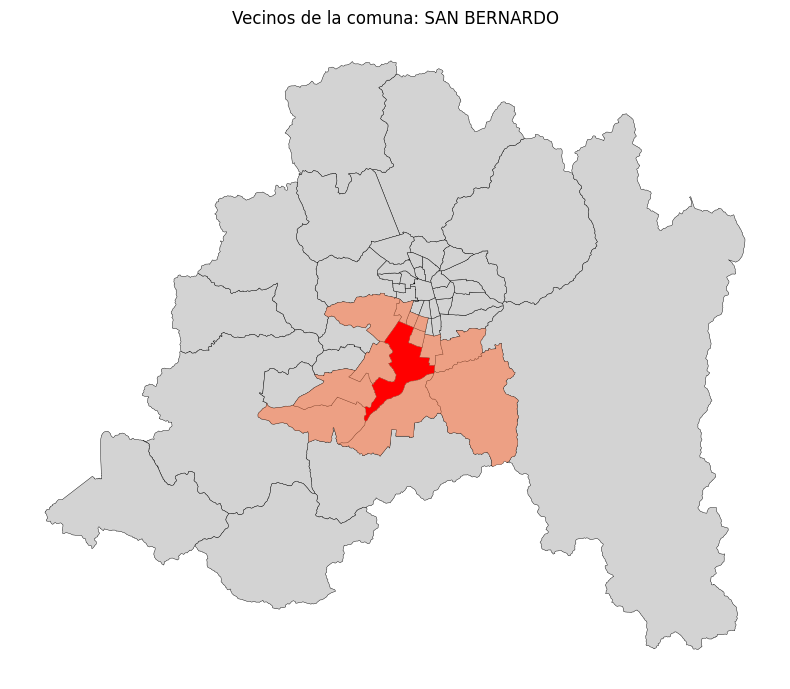

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

idx = 'SAN BERNARDO'

neighbors = list(w_queen.neighbors[idx])

rm_comunas_idx.plot(facecolor="lightgrey", edgecolor="k", linewidth=0.3, ax=ax)

rm_comunas_idx.loc[[idx]].plot(facecolor="red", ax=ax)

if neighbors:
    rm_comunas_idx.loc[neighbors].plot(facecolor="coral", alpha=0.6, ax=ax)

ax.set_axis_off()
ax.set_title(f"Vecinos de la comuna: {idx}")

plt.tight_layout()
plt.show()

### Parte C: Interpretación

Respondan: ¿La comuna con más vecinos es la misma en los tres métodos? ¿Por qué sí o por qué no?

**Respuesta:** San Bernardo es la comuna con mas vecinos en todos los métodos, debido a su gran tamaño natural.
Esto ocurre debido a que San Bernardo tiene una forma geográfica muy poco regular y con una forma poligonal, esto hace que tenga muchos vecinos.

---
## Ejercicio 3 — DistanceBand y el problema de las islas (20 min)

### Parte A: Umbral de 10 km

Construyan pesos espaciales de tipo `DistanceBand` con un umbral de **10.000 metros** (`binary=True`).

Respondan: ¿Hay comunas que quedan como **islas** (sin vecinos)? ¿Cuáles son? ¿Por qué creen que quedaron aisladas?

**Pista:** revisen el atributo `.islands` del objeto de pesos.

In [118]:
# Tu código aquí
w_stgo = weights.distance.DistanceBand.from_dataframe(rm_comunas_idx, 10000, binary=True)
print(w_stgo.islands)

['PAINE', 'BUIN', 'PUDAHUEL', 'COLINA', 'TILTIL', 'LAMPA', 'MARÍA PINTO', 'CURACAVÍ', 'LO BARNECHEA', 'MELIPILLA', 'SAN JOSÉ DE MAIPO', 'PIRQUE', 'EL MONTE', 'SAN PEDRO', 'ALHUÉ']


**Respuesta:** Si, existen comunas que quedan aisladas, esto ocurre porque hay comunas muy grandes y este umbral no es suficiente para encontrar vecinos. Por ejemplo la comuna de melipilla al ser tan grande no alcanza a tener vecinos, ya que tiene una superficie de mas de 1.300 km2.

### Parte B: Encontrar el umbral mínimo

Encuentren el **umbral mínimo** (en metros) que elimina todas las islas. Pueden probar manualmente o hacer un loop.

Visualicen el grafo de vecindad con ese umbral.

In [121]:
umbral = 10000
paso = 10000
max_intentos = 500000

while True:
    w_stgo = weights.distance.DistanceBand.from_dataframe(rm_comunas_idx, umbral, binary=True)
    islas = w_stgo.islands
    num_islas = len(islas)
    print(f"Umbral: {umbral}m | Islas encontradas: {num_islas}")
    if num_islas == 0:
        print(f"¡Éxito! A los {umbral} metros ya no quedan comunas aisladas.")
        break
    print(f"  > Comunas aisladas: {islas}")
    umbral += paso
    if umbral > max_intentos:
        print("Se alcanzó el límite de distancia máximo sin conectar todas las comunas.")
        break

Umbral: 10000m | Islas encontradas: 15
  > Comunas aisladas: ['PAINE', 'BUIN', 'PUDAHUEL', 'COLINA', 'TILTIL', 'LAMPA', 'MARÍA PINTO', 'CURACAVÍ', 'LO BARNECHEA', 'MELIPILLA', 'SAN JOSÉ DE MAIPO', 'PIRQUE', 'EL MONTE', 'SAN PEDRO', 'ALHUÉ']
Umbral: 20000m | Islas encontradas: 5
  > Comunas aisladas: ['COLINA', 'TILTIL', 'SAN JOSÉ DE MAIPO', 'SAN PEDRO', 'ALHUÉ']
Umbral: 30000m | Islas encontradas: 3
  > Comunas aisladas: ['SAN JOSÉ DE MAIPO', 'SAN PEDRO', 'ALHUÉ']
Umbral: 40000m | Islas encontradas: 0
¡Éxito! A los 40000 metros ya no quedan comunas aisladas.


---
## Ejercicio 4 — Tabla comparativa de síntesis (10 min)

Completen la siguiente tabla para las comunas de la RM. Usen los objetos de pesos que ya construyeron (o construyan los que falten).

| Método | `n` | `pct_nonzero` | ¿Tiene islas? | Cardinalidad promedio |
|--------|-----|---------------|---------------|----------------------|
| Queen | | | | |
| Rook | | | | |
| KNN k=5 | | | | |
| DistanceBand 10 km | | | | |

Respondan: Si tuvieran que elegir **un solo método** para analizar datos socioeconómicos por comuna en la RM, ¿cuál elegirían y por qué?

In [ ]:
# Tu código aquí


**Respuesta:** *(escribe tu interpretación aquí)*